# 相位相干测试：模拟数据生成

本 notebook 当前只生成测试数据，不进行小波变换或相干度计算。数组轴顺序固定为 $(x,y,t)$，波沿 $x$ 方向传播，且在 $y$ 方向均匀。

正向波为

$$
V_+(x,y,t)=A\left(t-\frac{x}{v_{\rm ph}}\right)\cos(k_0x-\omega_0t),
$$

反射层 $x=x_r$ 左侧的反向波为

$$
V_-(x,y,t)=rA\left(t-\frac{2x_r-x}{v_{\rm ph}}\right)\cos(-k_0x-\omega_0t+2k_0x_r+\phi_r).
$$

采用 `stmorlet` 默认参数 $k_{\rm M}=\omega_{\rm M}=6$、$\epsilon=1$。在目标 $(k_0,\omega_0)$ 处，小波的空间和时间高斯尺度为

$$
a_s=\frac{k_{\rm M}}{k_0},\qquad a_t=\frac{\omega_{\rm M}}{\omega_0}.
$$

数据边界按 $\pm4a_s$ 和 $\pm4a_t$ 留出裕量；高斯因子在 $4\sigma$ 处已经下降至 $e^{-8}\approx3.35\times10^{-4}$。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from stmorlet import Morlet2D1T

In [2]:
# -------------------- 采样与数组轴 --------------------
nx, ny, nt = 256, 128, 512
dx = dy = dt = 1.0
x = np.arange(nx, dtype=np.float64) * dx
y = np.arange(ny, dtype=np.float64) * dy
t = np.arange(nt, dtype=np.float64) * dt

# 广播后的第 0、1、2 轴依次对应 x、y、t
x3 = x[:, None, None]
t3 = t[None, None, :]
y_uniform = np.ones((1, ny, 1), dtype=np.float32)

# -------------------- 波与 Morlet 参数 --------------------
wavelength = 12.0 * dx
phase_speed = 1.0 * dx / dt
k = 2.0 * np.pi / wavelength
omega = k * phase_speed
period = 2.0 * np.pi / omega

morlet_k0 = 6.0
morlet_omega0 = 6.0
epsilon = 1.0
a_s = morlet_k0 / k
a_t = morlet_omega0 / omega
support_sigma = 4.0
margin_x = int(np.ceil(support_sigma * a_s / dx))
margin_y = int(np.ceil(support_sigma * np.sqrt(epsilon) * a_s / dy))
margin_t = int(np.ceil(support_sigma * a_t / dt))

# -------------------- 反射模型 --------------------
reflection_x = 176.0 * dx
reflection_amplitude = 0.5
reflection_phase = 0.0
reflection_taper_width = 4.0 * dx
analysis_x = (64.0 * dx, 112.0 * dx)

print(f'data shape (x, y, t): {(nx, ny, nt)}')
print(f'wavelength={wavelength:.2f}, period={period:.2f}')
print(f'a_s={a_s:.3f}, a_t={a_t:.3f}')
print(f'four-sigma margins: x={margin_x}, y={margin_y}, t={margin_t} samples')

data shape (x, y, t): (256, 128, 512)
wavelength=12.00, period=12.00
a_s=11.459, a_t=11.459
four-sigma margins: x=46, y=46, t=46 samples


In [3]:
# 非周期、非对称的公共包络，使时间延迟具有唯一、可识别的特征。
pulse_amplitudes = np.array([1.00, 0.65, 0.85], dtype=np.float64)
pulse_centers = np.array([40.0, 90.0, 140.0], dtype=np.float64) * dt
pulse_widths = np.array([18.0, 24.0, 15.0], dtype=np.float64) * dt

def envelope(retarded_time):
    result = np.zeros_like(retarded_time, dtype=np.float64)
    for amplitude, center, width in zip(
        pulse_amplitudes, pulse_centers, pulse_widths
    ):
        result += amplitude * np.exp(
            -0.5 * ((retarded_time - center) / width) ** 2
        )
    return result

# 沿 +x 传播：cos(kx - omega*t)
retarded_time_plus = t3 - x3 / phase_speed
phase_plus = k * x3 - omega * t3
v_plus_xt = envelope(retarded_time_plus) * np.cos(phase_plus)
v_plus = (v_plus_xt * y_uniform).astype(np.float32)

# 沿 -x 传播。平滑门函数只让反射波存在于反射层左侧；
# 后续分析区域与门函数之间保留超过 4 sigma 的空间距离。
retarded_time_minus = t3 - (2.0 * reflection_x - x3) / phase_speed
phase_minus = (
    -k * x3 - omega * t3 + 2.0 * k * reflection_x + reflection_phase
)
reflection_gate = 0.5 * (
    1.0 - np.tanh((x3 - reflection_x) / reflection_taper_width)
)
v_minus_xt = (
    reflection_amplitude
    * reflection_gate
    * envelope(retarded_time_minus)
    * np.cos(phase_minus)
)
v_minus = (v_minus_xt * y_uniform).astype(np.float32)

# 第一轮为无噪声、单层反射数据。
data = v_plus + v_minus

assert data.shape == (nx, ny, nt)
assert data.dtype == np.float32
assert analysis_x[0] >= margin_x * dx
assert reflection_x - analysis_x[1] >= margin_x * dx
assert ny * dy >= 2.0 * margin_y * dy

expected_delay_range = (
    2.0 * (reflection_x - analysis_x[1]) / phase_speed,
    2.0 * (reflection_x - analysis_x[0]) / phase_speed,
)
print(f'data dtype: {data.dtype}')
print(f'analysis x range: {analysis_x}')
print(f'expected delay range in analysis region: {expected_delay_range}')

data dtype: float32
analysis x range: (64.0, 112.0)
expected delay range in analysis region: (128.0, 224.0)


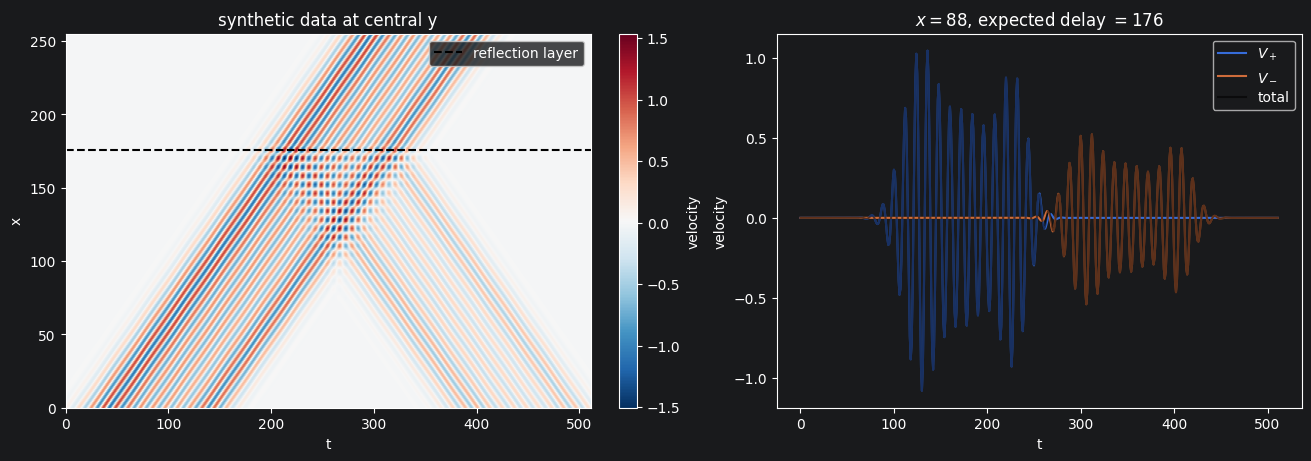

In [3]:
# 仅检查生成的数据，不进行小波或相干分析。
y_index = ny // 2
x_observe = 88.0 * dx
x_index = int(round(x_observe / dx))
expected_delay = 2.0 * (reflection_x - x[x_index]) / phase_speed

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
extent = [t[0], t[-1], x[0], x[-1]]
image = axes[0].imshow(
    data[:, y_index, :],
    origin='lower',
    aspect='auto',
    extent=extent,
    cmap='RdBu_r',
)
axes[0].axhline(reflection_x, color='black', linestyle='--', label='reflection layer')
axes[0].set(xlabel='t', ylabel='x', title='synthetic data at central y')
axes[0].legend()
fig.colorbar(image, ax=axes[0], label='velocity')

axes[1].plot(t, v_plus[x_index, y_index], label=r'$V_+$')
axes[1].plot(t, v_minus[x_index, y_index], label=r'$V_-$')
axes[1].plot(t, data[x_index, y_index], color='black', alpha=0.55, label='total')
axes[1].set(
    xlabel='t',
    ylabel='velocity',
    title=fr'$x={x[x_index]:.0f}$, expected delay $={expected_delay:.0f}$',
)
axes[1].legend()
plt.show()

In [4]:
morlet = Morlet2D1T(
    dx=dx,
    dy=dy,
    dt=dt,
    epsilon=epsilon,
    k0=6,
    omega0=6.0,
    precision="single",
    backend="gpu",
    device=0,
    boundary=None,
)

In [5]:
k_array = k * np.linspace(0.5, 1.5, 9)
omega_array = omega * np.linspace(0.5, 1.5, 9)
theta_array = np.linspace(-10, 10, 9) + 180

In [6]:
psd_plus_path = morlet.psd_polar(v_plus, k_array, theta_array, omega_array, output="memmap", path='./data/test_psd_plus.npy', overwrite=True)

PSD polar:   0%|          | 0/9 [00:00<?, ?block/s]

In [7]:
psd_plus = np.load('./data/test_psd_plus.npy', mmap_mode="r")
psd_plus_f = np.mean(psd_plus, axis=(0, 1, 2))

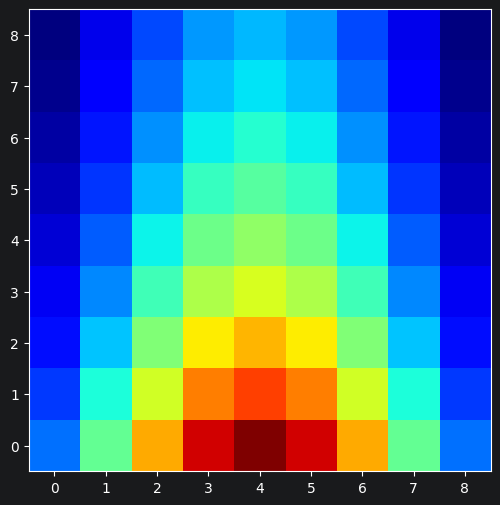

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.mean(psd_plus_f, axis=2), origin='lower', cmap='jet')

In [10]:
k_array = k * np.linspace(0.5, 1.5, 9)
omega_array = omega * np.linspace(0.5, 1.5, 9)
theta_plus_array = np.linspace(-10, 10, 9)
theta_minus_array = 180 + theta_plus_array

In [12]:
w_test_plus = morlet.cwt_polar(data, k_array, theta_plus_array, omega_array, output="memmap", path='./data/test_coe_plus.npy', overwrite=True)
w_test_minus = morlet.cwt_polar(data, k_array, theta_minus_array, omega_array, output="memmap", path='./data/test_coe_minus.npy', overwrite=True)

CWT polar:   0%|          | 0/9 [00:00<?, ?block/s]

CWT polar:   0%|          | 0/9 [00:00<?, ?block/s]

In [13]:
w_plus = np.load('./data/test_coe_plus.npy', mmap_mode="r")[64:113, 46:82, 46:466, 4, 4, 4]
w_minus = np.load('./data/test_coe_minus.npy', mmap_mode="r")[64:113, 46:82, 46:466, 4, 4, 4]

In [14]:
lag_array = np.arange(100, 241, dtype=int)

nx_valid, ny_valid, nt_valid = w_plus.shape
max_lag = lag_array.max()
n_common = nt_valid - max_lag

gamma2 = np.full((nx_valid, len(lag_array)), np.nan, dtype=np.float64)

wp = w_plus[:, :, :n_common]

power_plus = np.mean(np.abs(wp) ** 2, axis=(1, 2))

for i, lag in enumerate(lag_array):
    wm = w_minus[:, :, lag:lag + n_common]
    s_pm = np.mean(wp * np.conj(wm), axis=(1, 2))
    power_minus = np.mean(np.abs(wm) ** 2, axis=(1, 2))
    denominator = power_plus * power_minus

    np.divide(
        np.abs(s_pm) ** 2,
        denominator,
        out=gamma2[:, i],
        where=denominator > 0,
    )

gamma2 = np.clip(gamma2, 0.0, 1.0)

In [16]:
x_valid = x[64:113]
tau_array = lag_array * dt

tau_theory = (
    2.0 * (reflection_x - x_valid)
    / phase_speed
)

best_index = np.nanargmax(gamma2, axis=1)
tau_measured = tau_array[best_index]
gamma2_max = gamma2[np.arange(nx_valid), best_index]

delay_error = tau_measured - tau_theory

print("gamma2 range:",
      np.nanmin(gamma2), np.nanmax(gamma2))
print("mean peak gamma2:",
      np.nanmean(gamma2_max))
print("mean absolute delay error:",
      np.nanmean(np.abs(delay_error)))

gamma2 range: 0.18404853343963623 1.0
mean peak gamma2: 0.9999999744551522
mean absolute delay error: 0.0


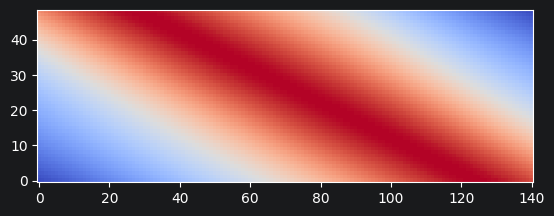

In [17]:
fig, ax = plt.subplots()
ax.imshow(gamma2, origin='lower', cmap='coolwarm')